In [136]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau


In [137]:

# Data Preprocessing with ENHANCED feature engineering
df = pd.read_csv("housing.csv")

# Handle missing values
df['AveBedrms'].fillna(df['AveBedrms'].median(), inplace=True)

# ENHANCED Feature engineering
df['rooms_per_household'] = df['AveRooms'] 
df['bedrooms_per_room'] = df['AveBedrms'] / df['AveRooms']
df['population_per_household'] = df['Population'] / df['AveOccup']
df['income_per_room'] = df['MedInc'] / df['AveRooms']

# Polynomial features
df['house_age_squared'] = df['HouseAge'] ** 2
df['income_squared'] = df['MedInc'] ** 2
df['rooms_squared'] = df['AveRooms'] ** 2
df['latitude_squared'] = df['Latitude'] ** 2
df['longitude_squared'] = df['Longitude'] ** 2

# More interaction features
df['lat_long_interaction'] = df['Latitude'] * df['Longitude']
df['income_age_interaction'] = df['MedInc'] * df['HouseAge']
df['income_rooms_interaction'] = df['MedInc'] * df['AveRooms']
df['age_rooms_interaction'] = df['HouseAge'] * df['AveRooms']

# Distance-based features
df['dist_to_coast'] = df['Longitude'].max() - df['Longitude']
df['dist_to_center'] = np.sqrt((df['Latitude'] - df['Latitude'].mean())**2 + 
                              (df['Longitude'] - df['Longitude'].mean())**2)

# Density features
df['room_density'] = df['AveRooms'] / df['Population']
df['household_density'] = df['AveOccup'] / df['Population']

# Income brackets (binning)
df['income_high'] = (df['MedInc'] > df['MedInc'].quantile(0.75)).astype(int)
df['income_low'] = (df['MedInc'] < df['MedInc'].quantile(0.25)).astype(int)

# Apply log transformations
df['MedInc'] = np.log1p(df['MedInc'])
df['Population'] = np.log1p(df['Population'])

# One-hot encoding
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

# Rest of preprocessing...
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal'].values.reshape(-1, 1)

# Scale features and target
X_scaler = StandardScaler()
y_scaler = StandardScaler()
X_scaled = X_scaler.fit_transform(X)
y_scaled = y_scaler.fit_transform(y)

# Convert to PyTorch tensors
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y_scaled, dtype=torch.float32)

# Split dataset
X_train, X_temp, y_train, y_temp = train_test_split(X_tensor, y_tensor, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Create datasets and dataloaders
train_ds = TensorDataset(X_train, y_train)
val_ds = TensorDataset(X_val, y_val)
test_ds = TensorDataset(X_test, y_test)

train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=32)
test_dl = DataLoader(test_ds, batch_size=32)

print(f"Features shape: {X_tensor.shape}")
print(f"Target shape: {y_tensor.shape}")
print(f"Training set: {len(train_ds)}")
print(f"Validation set: {len(val_ds)}")
print(f"Test set: {len(test_ds)}")


Features shape: torch.Size([20640, 31])
Target shape: torch.Size([20640, 1])
Training set: 14448
Validation set: 3096
Test set: 3096


C:\Users\shaha\AppData\Local\Temp\ipykernel_28424\3122983929.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['AveBedrms'].fillna(df['AveBedrms'].median(), inplace=True)


In [138]:
class CaliforniaHousingPredictor(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.network = nn.Sequential(
    nn.Linear(input_size, 128),
    nn.ReLU(),
    nn.BatchNorm1d(128),
    nn.Dropout(0.3),
    nn.Linear(128, 128),  
    
    nn.BatchNorm1d(128),
    nn.Dropout(0.2),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1)
)

        
    
    def forward(self, x):
        return self.network(x)


In [140]:
model = CaliforniaHousingPredictor(X_tensor.shape[1])
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.001)
scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=5)

best_loss = float('inf')
patience = 10
patience_counter = 0

for epoch in range(100):
    model.train()
    for xb, yb in train_dl:
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        optimizer.zero_grad()

    model.eval()
    with torch.no_grad():
        val_preds = model(X_val)
        val_loss = criterion(val_preds, y_val)

    val_rmse = torch.sqrt(val_loss).item()
    print(f"Epoch {epoch+1}, Val RMSE: {val_rmse:.4f}")

    scheduler.step(val_loss)

    if val_loss < best_loss:
        best_loss = val_loss
        best_model_state = model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"No improvement. Patience count: {patience_counter}/{patience}")
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

# Load best model
model.load_state_dict(best_model_state)


c:\Users\shaha\anaconda3\envs\california-env\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1, Val RMSE: 0.5394
Epoch 2, Val RMSE: 0.5288
Epoch 3, Val RMSE: 0.5216
Epoch 4, Val RMSE: 0.5290
No improvement. Patience count: 1/10
Epoch 5, Val RMSE: 0.5383
No improvement. Patience count: 2/10
Epoch 6, Val RMSE: 0.5274
No improvement. Patience count: 3/10
Epoch 7, Val RMSE: 0.5417
No improvement. Patience count: 4/10
Epoch 8, Val RMSE: 0.5099
Epoch 9, Val RMSE: 0.5040
Epoch 10, Val RMSE: 0.5043
No improvement. Patience count: 1/10
Epoch 11, Val RMSE: 0.4965
Epoch 12, Val RMSE: 0.5029
No improvement. Patience count: 1/10
Epoch 13, Val RMSE: 0.4965
No improvement. Patience count: 2/10
Epoch 14, Val RMSE: 0.5118
No improvement. Patience count: 3/10
Epoch 15, Val RMSE: 0.5019
No improvement. Patience count: 4/10
Epoch 16, Val RMSE: 0.5332
No improvement. Patience count: 5/10
Epoch 17, Val RMSE: 0.5106
No improvement. Patience count: 6/10
Epoch 18, Val RMSE: 0.4779
Epoch 19, Val RMSE: 0.4822
No improvement. Patience count: 1/10
Epoch 20, Val RMSE: 0.4914
No improvement. Patience 

<All keys matched successfully>

In [ ]:
# Generate predictions from the single model
model.eval()
with torch.no_grad():
    test_preds = model(X_test)

# Convert to numpy
test_preds_np = test_preds.numpy()
y_true = y_test.numpy()

# Inverse scaling
y_true_inv = y_scaler.inverse_transform(y_true)
preds_inv = y_scaler.inverse_transform(test_preds_np)

rmse = np.sqrt(mean_squared_error(y_true_inv, preds_inv))
mae = mean_absolute_error(y_true_inv, preds_inv)
r2 = r2_score(y_true_inv, preds_inv)

print("\n Model Evaluation Metrics:")
print(f"✅ RMSE: {rmse:.4f}")
print(f"✅ MAE : {mae:.4f}")
print(f"✅ R²  : {r2:.4f}")

if r2 >= 0.85:
    print(" SUCCESS! R² target of 0.85 achieved!")
else:
    print(f" Progress: Need {0.85 - r2:.4f} more to reach 0.85")


🔍 Evaluation Metrics:
✅ RMSE: 0.5228
✅ MAE : 0.3709
✅ R²  : 0.7933


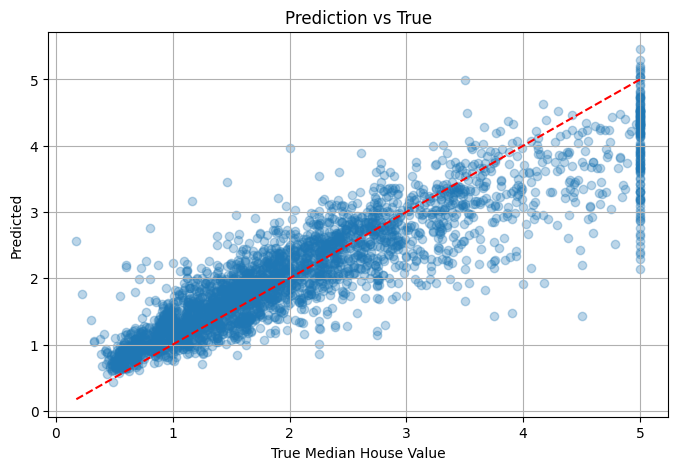

In [142]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(y_true_inv, preds_inv, alpha=0.3)
plt.plot([y_true_inv.min(), y_true_inv.max()],
         [y_true_inv.min(), y_true_inv.max()], 'r--')
plt.xlabel("True Median House Value")
plt.ylabel("Predicted")
plt.title("Prediction vs True")
plt.grid()
plt.show()
